# Home Credit Default Risk — Data Exploration

## Project Goal

The goal of this project is to investigate whether an applicant's
financial, demographic, and historical characteristics are associated
with difficulty repaying a loan.

This notebook explores the main application dataset to:

- Understand the structure and quality of the data
- Examine the target variable
- Identify patterns associated with repayment difficulty
- Create a small number of exploratory variables
- Identify potential data-quality issues for later preprocessing

The findings from this exploration will guide the preprocessing,
feature engineering, and modeling stages of the project.

## Contents

1. Dataset Overview
2. Target Variable
3. Applicant Characteristics
4. Credit-to-Income Ratio
5. Income Type
6. Education
7. Family Status
8. Employment History
9. Annuity-to-Income Ratio
10. Housing Type
11. Missing Values
12. Data Quality Observations
13. Overall EDA Findings

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('../data/application_train.csv')
test = pd.read_csv('../data/application_test.csv')

print("Train data shape:", train.shape)
print("Test data shape:", test.shape)

print("First 5 rows:")
display(train.head())

print("\nDataset information:")
train.info()

print("\nSummary statistics:")
display(train.describe())

Train data shape: (307511, 122)
Test data shape: (48744, 121)
First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB

Summary statistics:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


### Initial Observations

The training dataset contains 307,511 applicants and 106 columns,
including the target variable.

The dataset contains a mixture of numerical and categorical variables,
including information about income, credit, employment, education,
housing, and family status.

Several variables contain missing values or unusual values that will
require further investigation before modeling.

## Target Variable

TARGET represents loan repayment difficulty.

- 0 = Loan repaid without difficulty
- 1 = Loan repayment difficulty


Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


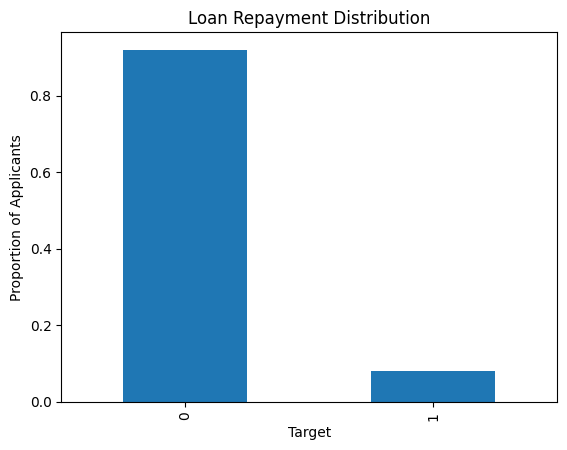

In [159]:
print("\nTarget distribution:")
print(train ["TARGET"].value_counts(normalize=True))

train ["TARGET"].value_counts(normalize=True).plot.bar()

plt.title("Loan Repayment Distribution")
plt.xlabel("Target")
plt.ylabel("Proportion of Applicants")
plt.show()

### Finding

Approximately 92% of applicants did not experience repayment difficulty, while approximately 8% did.

- The target variable is imbalanced, with approximately 8% of applicants experiencing repayment difficulties.
- Income varies substantially across applicants, with the mean income higher than the median.
- Age and employment length are stored as the number of days relative to the application date.
- Some variables contain unusual values that may require further investigation during data cleaning.

## Applicant Characteristics

I will compare income, credit amount, and age between applicants with and without repayment difficulties.

In [160]:
print("Average income by target:")
print(train.groupby("TARGET")["AMT_INCOME_TOTAL"].mean())

print("\nAverage credit amount by target:")
print(train.groupby("TARGET")["AMT_CREDIT"].mean())

train["AGE_YEARS"] = -train["DAYS_BIRTH"] / 365

print("\nAverage age by target:")
print(train.groupby("TARGET")["AGE_YEARS"].mean())

Average income by target:
TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

Average credit amount by target:
TARGET
0    602648.282002
1    557778.527674
Name: AMT_CREDIT, dtype: float64

Average age by target:
TARGET
0    44.214182
1    40.780351
Name: AGE_YEARS, dtype: float64


/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_53692/3701922047.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["AGE_YEARS"] = -train["DAYS_BIRTH"] / 365


## Findings: Applicant Characteristics

The average income is slightly lower among applicants who experienced
repayment difficulties, although the difference is relatively small.

Applicants with repayment difficulties also have a lower average credit
amount than applicants without repayment difficulties.

The largest difference among these three variables is age. Applicants
with repayment difficulties are approximately 3.4 years younger on
average.

These differences show potential relationships between applicant
characteristics and repayment difficulty, but they do not establish
causation.

### Age and Repayment Difficulty

The average age differs between applicants who experienced repayment
difficulties and those who did not. I will visualize the age distributions
to see whether this difference appears across the data.

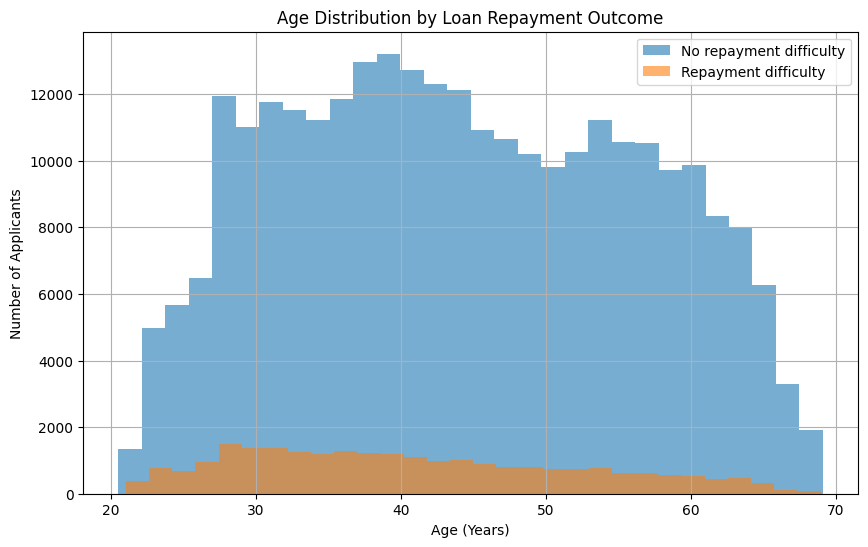

In [161]:
plt.figure(figsize=(10, 6))

train[train["TARGET"] == 0]["AGE_YEARS"].hist(
    bins=30,
    alpha=0.6,
    label="No repayment difficulty"
)

train[train["TARGET"] == 1]["AGE_YEARS"].hist(
    bins=30,
    alpha=0.6,
    label="Repayment difficulty"
)

plt.title("Age Distribution by Loan Repayment Outcome")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Applicants")
plt.legend()
plt.show()

### Finding

The two age distributions overlap substantially, so age alone does not
clearly distinguish applicants with repayment difficulties from those
without them.

The repayment-difficulty group is much smaller overall, reflecting the
class imbalance in the target variable. There also appears to be a gradual
decline in the number of applicants experiencing repayment difficulties
from around age 35 onward.

Age may therefore provide useful information to the model, but it is
unlikely to be sufficient on its own to predict repayment difficulty.

In [162]:
train["CREDIT_INCOME_RATIO"] = (
    train["AMT_CREDIT"] / train["AMT_INCOME_TOTAL"]
)

/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_53692/807241078.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["CREDIT_INCOME_RATIO"] = (


### Notes:

loan amount / income = Credit-to-income ration
```python
train["CREDIT_INCOME_RATIO"]
```
creates a new column called CREDIT_INCOME_RATIO

The credit-to-income ratio measures the size of an applicant's requested
credit relative to their total income.

Credit-to-Income Ratio = Credit Amount / Income

In [163]:
train[["AMT_INCOME_TOTAL", "AMT_CREDIT", "CREDIT_INCOME_RATIO"]].head()

,AMT_INCOME_TOTAL,AMT_CREDIT,CREDIT_INCOME_RATIO
0,202500.0,406597.5,2.007889
1,270000.0,1293502.5,4.790750
2,67500.0,135000.0,2.000000
3,135000.0,312682.5,2.316167
4,121500.0,513000.0,4.222222


In [164]:
train.groupby("TARGET")["CREDIT_INCOME_RATIO"].mean()

TARGET
0    3.963729
1    3.887438
Name: CREDIT_INCOME_RATIO, dtype: float64

### Finding

The average credit-to-income ratio is similar for both repayment groups.
Applicants without repayment difficulties have an average ratio of
approximately 3.96, compared with 3.89 for applicants with repayment
difficulties.

This small difference suggests that the average credit-to-income ratio
alone may not strongly distinguish the two groups. Further analysis is
needed to understand whether the relationship changes across different
levels of income or credit.

## Credit-to-Income Ratio Distribution


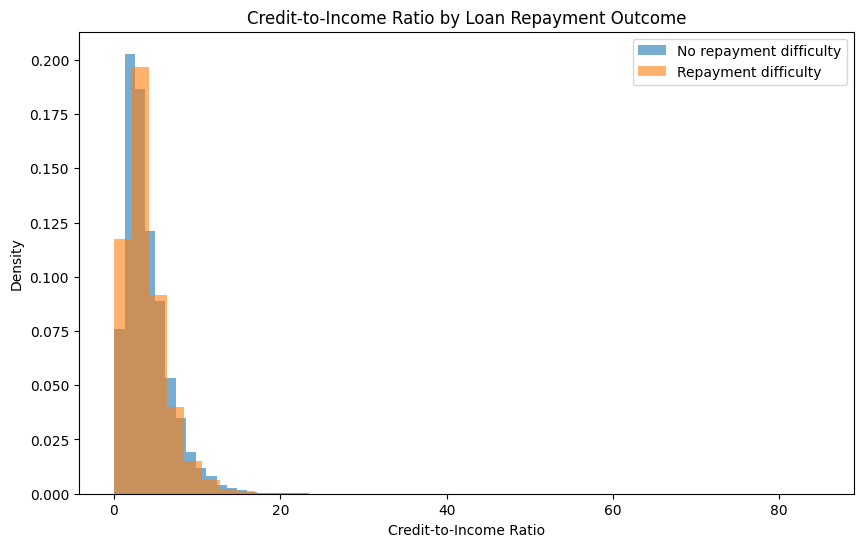

In [165]:
plt.figure(figsize=(10, 6))

train[train["TARGET"] == 0]["CREDIT_INCOME_RATIO"].plot.hist(
    bins=40,
    density=True,
    alpha=0.6,
    label="No repayment difficulty"
)

train[train["TARGET"] == 1]["CREDIT_INCOME_RATIO"].plot.hist(
    bins=40,
    density=True,
    alpha=0.6,
    label="Repayment difficulty"
)

plt.title("Credit-to-Income Ratio by Loan Repayment Outcome")
plt.xlabel("Credit-to-Income Ratio")
plt.ylabel("Density")
plt.legend()
plt.show()

## Income Type and Repayment Difficulty

I will compare repayment difficulty rates across different income types
to determine whether repayment outcomes vary between these groups.

NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64


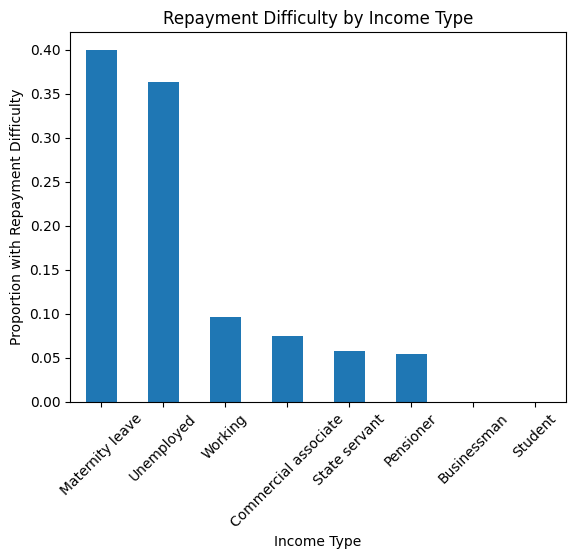

In [166]:
income_type_risk = (
    train.groupby("NAME_INCOME_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(income_type_risk)

income_type_risk.plot.bar()

plt.title("Repayment Difficulty by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Proportion with Repayment Difficulty")
plt.xticks(rotation=45)
plt.show()

In [167]:
income_type_counts = train["NAME_INCOME_TYPE"].value_counts()

print(income_type_counts)

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


### Finding

Repayment difficulty rates vary across income types, but the sample size
of each group must be considered when interpreting these differences.

Maternity leave, unemployed, student, and businessman groups have very
few applicants, making their repayment difficulty rates less reliable.

The largest groups are working, commercial associates, pensioners, and
state servants, so differences among these groups provide more meaningful
comparisons.

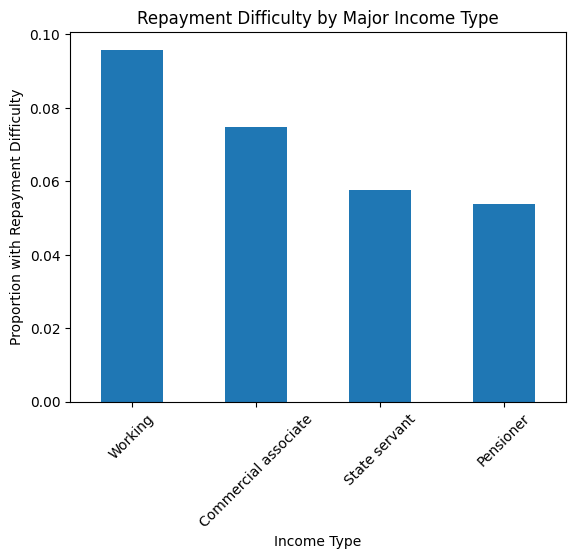

NAME_INCOME_TYPE
Working                 9.588472
Commercial associate    7.484257
State servant           5.754965
Pensioner               5.386366
Name: TARGET, dtype: float64


In [168]:
main_income_types = [
    "Working",
    "Commercial associate",
    "Pensioner",
    "State servant"
]

main_income_data = train[
    train["NAME_INCOME_TYPE"].isin(main_income_types)
]

main_income_data.groupby("NAME_INCOME_TYPE")["TARGET"].mean().sort_values(
    ascending=False
).plot.bar()
plt.title("Repayment Difficulty by Major Income Type")
plt.xlabel("Income Type")
plt.ylabel("Proportion with Repayment Difficulty")
plt.xticks(rotation=45)
plt.show()

income_rates = main_income_data.groupby("NAME_INCOME_TYPE")["TARGET"].mean().sort_values(
    ascending=False) * 100

print(income_rates)

NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64


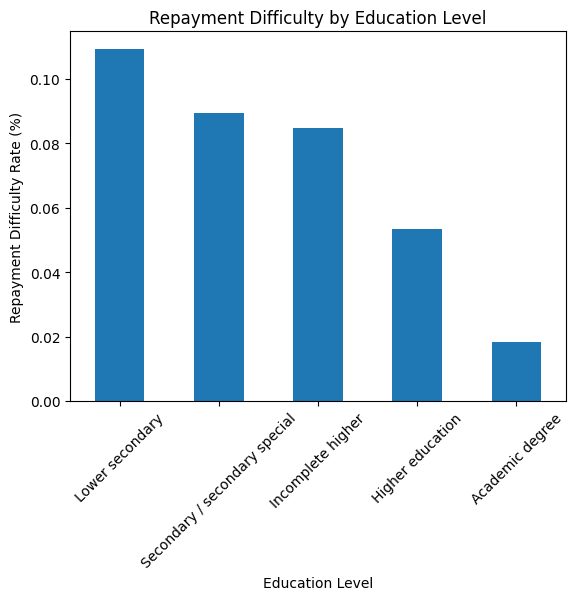

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64


In [169]:
## Education and Repayment Difficulty

education_risk = (
    train.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(education_risk * 100)
education_risk.plot.bar()

plt.title("Repayment Difficulty by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Repayment Difficulty Rate (%)")
plt.xticks(rotation=45)
plt.show()
education_counts = train["NAME_EDUCATION_TYPE"].value_counts()

print(education_counts)


### Finding

Repayment difficulty rates varied across education levels.

Applicants with lower secondary education had the highest repayment
difficulty rate at approximately 10.9%, while applicants with higher
education had a rate of approximately 5.4%.

The academic degree group had the lowest rate at approximately 1.8%.
However, this group contained only 164 applicants, so this result should
be interpreted cautiously.

Overall, education level appears to provide potentially useful
information for predicting repayment difficulty.

NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64


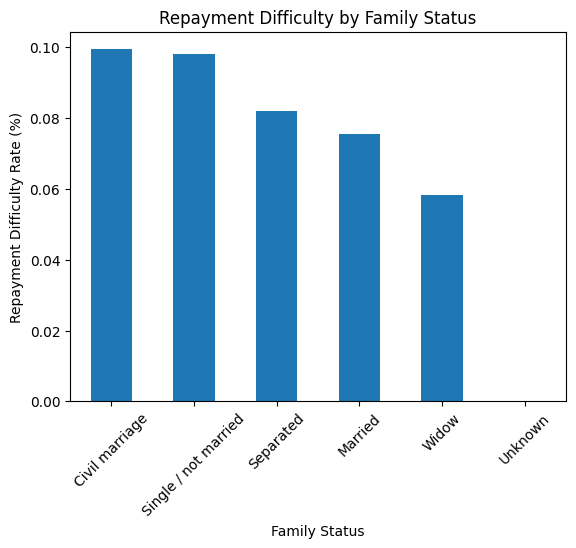

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


In [170]:
family_risk = (
    train.groupby("NAME_FAMILY_STATUS")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(family_risk * 100)
family_risk.plot.bar()

plt.title("Repayment Difficulty by Family Status")
plt.xlabel("Family Status")
plt.ylabel("Repayment Difficulty Rate (%)")
plt.xticks(rotation=45)
plt.show()
print(train["NAME_FAMILY_STATUS"].value_counts())

### Finding

Repayment difficulty rates varied across family-status groups.

Civil marriage and single or not married applicants had the highest
repayment difficulty rates at approximately 9.9% and 9.8%, respectively.

Married applicants had a lower rate of approximately 7.6%, while widowed
applicants had the lowest rate among the larger groups at approximately
5.8%.

The Unknown category contained only two applicants and was therefore not
considered meaningful for interpretation.

In [171]:
train["DAYS_EMPLOYED_CLEAN"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)

train["EMPLOYED_YEARS"] = -train["DAYS_EMPLOYED_CLEAN"] / 365

print(train.groupby("TARGET")["EMPLOYED_YEARS"].mean())

TARGET
0    6.679836
1    4.972380
Name: EMPLOYED_YEARS, dtype: float64


/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_53692/589685635.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["DAYS_EMPLOYED_CLEAN"] = train["DAYS_EMPLOYED"].replace(365243, np.nan)
/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_53692/589685635.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["EMPLOYED_YEARS"] = -train["DAYS_EMPLOYED_CLEAN"] / 365


### Finding

Applicants experiencing repayment difficulties had an average employment
length of approximately 5.0 years, compared with approximately 6.7 years
for applicants without repayment difficulties.

This difference suggests that employment history may provide useful
information for predicting repayment difficulty.

In [172]:
train["ANNUITY_INCOME_RATIO"] = (
    train["AMT_ANNUITY"] / train["AMT_INCOME_TOTAL"]
)

print(train.groupby("TARGET")["ANNUITY_INCOME_RATIO"].mean()) 

TARGET
0    0.180530
1    0.185482
Name: ANNUITY_INCOME_RATIO, dtype: float64


/var/folders/y1/p0h0n89x6c530xhk72bbnww40000gn/T/ipykernel_53692/3913636924.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train["ANNUITY_INCOME_RATIO"] = (


### Finding

The average annuity-to-income ratio was very similar between the two
groups: approximately 18.1% for applicants without repayment difficulty
and 18.5% for applicants experiencing repayment difficulty.

The small difference suggests that the average ratio alone may provide
limited predictive information.

NAME_HOUSING_TYPE
Rented apartment       12.313051
With parents           11.698113
Municipal apartment     8.539748
Co-op apartment         7.932264
House / apartment       7.795711
Office apartment        6.572411
Name: TARGET, dtype: float64


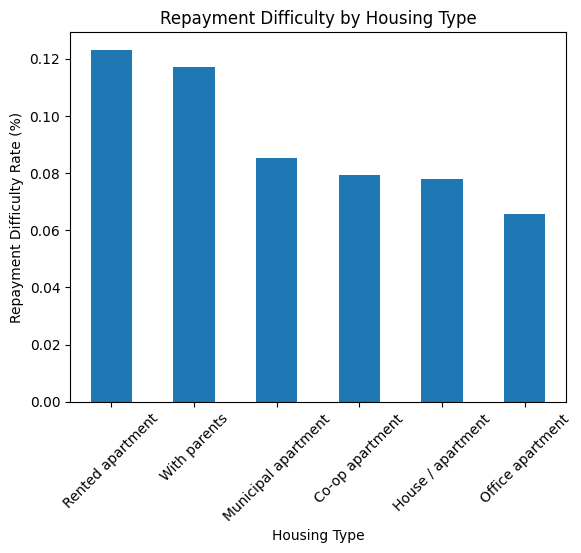

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64


In [173]:
housing_risk = (
    train.groupby("NAME_HOUSING_TYPE")["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

print(housing_risk * 100)

housing_risk.plot.bar()

plt.title("Repayment Difficulty by Housing Type")
plt.xlabel("Housing Type")
plt.ylabel("Repayment Difficulty Rate (%)")
plt.xticks(rotation=45)
plt.show()

print(train["NAME_HOUSING_TYPE"].value_counts())

### Finding

Repayment difficulty rates varied across housing types.

Applicants living in rented apartments had the highest repayment difficulty
rate at approximately 12.3%, followed by applicants living with parents at
approximately 11.7%.

Applicants living in a house or apartment had a lower repayment difficulty
rate of approximately 7.8%.

The smaller co-op apartment and office apartment groups should be interpreted
with some caution because they contain substantially fewer applicants.

Overall, housing type appears to contain potentially useful information
for predicting repayment difficulty, although these results represent
associations rather than causation.

In [174]:
missing = train.isnull().sum().sort_values(ascending=False)

missing_percent = (
    train.isnull().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

display(missing_summary.head(20))

,Missing Count,Missing Percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


## Missing Values

Missing values are common in the application dataset. Rather than
immediately filling or removing them, I first examined their frequency
and distribution.

The appropriate treatment of missing values will be determined during
the preprocessing stage.

## Data Quality Observations

The exploration identified several data-quality considerations that will
need to be addressed before modeling:

- The target variable is highly imbalanced.
- Several features contain missing values.
- `DAYS_BIRTH` and `DAYS_EMPLOYED` are stored as negative day counts.
- `DAYS_EMPLOYED` contains a special value of `365243` that requires
  separate treatment.
- Several categorical variables contain groups with very small sample
  sizes.
- Some numerical variables have highly skewed distributions and may
  contain extreme values.

These issues will be addressed during the preprocessing stage.

# Overall EDA Findings

The exploratory analysis identified several applicant characteristics
that appear to be associated with repayment difficulty.

Age and employment history showed noticeable differences between
applicants with and without repayment difficulties. Repayment difficulty
rates also varied across income type, education level, family status,
and other applicant characteristics.

In contrast, the average credit-to-income ratio and
annuity-to-income ratio were relatively similar between the two groups.

The analysis also identified several data-quality considerations,
including class imbalance, missing values, special values, and small
categorical groups.

These findings will guide the preprocessing and modeling stages of the
project. The relationships identified during EDA represent associations
within the dataset and should not be interpreted as evidence of causation.